# The FracAtlas Dataset
Consists of X-Ray scans from 3 major hospitals in Bangladesh.
It consists of 4,083 images that have been manually annotated for bone fracture classification, focusing on the following:
 * hand
 * shoulder
 * leg, and
 * hip regions.

X-ray scans of focusing on other parts of the body, such as chest or skull, were not included in this dataset.

For more information about data gathering and annotation, the original paper can be found at https://www.nature.com/articles/s41597-023-02432-4, and the original dataset can be found at https://doi.org/10.6084/m9.figshare.22363012. The total size of the dataset is 323 MB.



# Exploratory Data Analysis
In this section, we aim to explore the dataset to understand the distribution of the data.

In [2]:
import polars as pl
import matplotlib.pyplot as plt
import numpy as np
import os
from PIL import Image

### FracAtlas/dataset.csv
There is a CSV file provided in the dataset containing information about each image. It contains categories, but for this study, we will focus more on **hand, leg, hip, and shoulder**, and if it is **fractured, or not**.

In [3]:
df = pl.read_csv("../FracAtlas/dataset.csv")
df.head()

image_id,hand,leg,hip,shoulder,mixed,hardware,multiscan,fractured,fracture_count,frontal,lateral,oblique
str,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64
"""IMG0000000.jpg""",0,1,0,0,0,0,1,0,0,1,1,0
"""IMG0000001.jpg""",0,1,0,0,0,0,1,0,0,1,1,0
"""IMG0000002.jpg""",0,1,0,0,0,0,1,0,0,1,1,0
"""IMG0000003.jpg""",0,1,0,0,0,0,1,0,0,0,1,1
"""IMG0000004.jpg""",0,1,0,0,0,0,1,0,0,0,1,1


Here is an aggregated form of the dataset.

In [4]:
class_counts = df["fractured"].value_counts().sort("fractured")
class_counts

fractured,count
i64,u32
0,3366
1,717


For the fractured column, 0 represents no fracture, and 1 represents the presence of a fracture.
* Fractured:      3366 (82.44%)
* Not fractured:  717 (17.56%)

In this dataset, there are more non-fractured images than fractured images.

A visualization of the distribution is shown below.

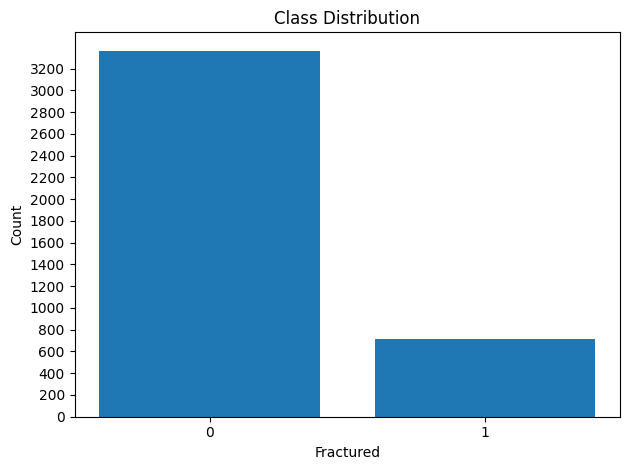

In [15]:
plt.bar(class_counts["fractured"].cast(pl.String), class_counts["count"])
plt.xlabel("Fractured")
plt.ylabel("Count")
plt.yticks(np.arange(0, class_counts["count"].max() + 1, 200))  # Use logarithmic scale for better visibility
plt.title("Class Distribution")
plt.tight_layout()
plt.show()

### Distribution of image regions
This dataset focuses on the following regions only:
 * hand
 * shoulder
 * leg, and
 * hip regions.



The dataset consists of different body regions, and this is a visualization of the distribution of each region.

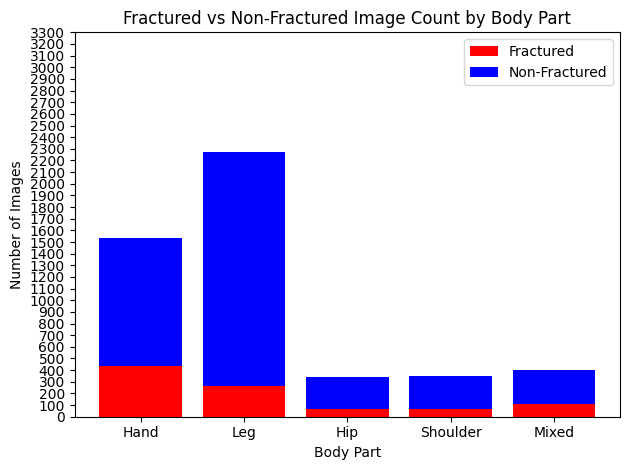

438 263 63 63 106


In [19]:
fractures = df["fractured"]

# Count fractured images per body part (fractured == 1)
fractured_hand_counts = df["hand"].filter(fractures == 1).sum()
fractured_leg_counts = df["leg"].filter(fractures == 1).sum()
fractured_hip_counts = df["hip"].filter(fractures == 1).sum()
fractured_shoulder_counts = df["shoulder"].filter(fractures == 1).sum()
fractured_mixed_counts = df["mixed"].filter(fractures == 1).sum()

# Count non-fractured images per body part (fractured == 0)
non_fractured_hand_counts = df["hand"].filter(fractures == 0).sum()
non_fractured_leg_counts = df["leg"].filter(fractures == 0).sum()
non_fractured_hip_counts = df["hip"].filter(fractures == 0).sum()
non_fractured_shoulder_counts = df["shoulder"].filter(fractures == 0).sum()
non_fractured_mixed_counts = df["mixed"].filter(fractures == 0).sum()

labels = ["Hand", "Leg", "Hip", "Shoulder", "Mixed"]

fractured_counts = [fractured_hand_counts, fractured_leg_counts, fractured_hip_counts,
                    fractured_shoulder_counts, fractured_mixed_counts]

non_fractured_counts = [non_fractured_hand_counts, non_fractured_leg_counts, non_fractured_hip_counts,
                        non_fractured_shoulder_counts, non_fractured_mixed_counts]

# Stacked bar: red = fractured, blue = non-fractured stacked on top
plt.bar(labels, fractured_counts, color='r', label='Fractured')
plt.bar(labels, non_fractured_counts, bottom=fractured_counts, color='b', label='Non-Fractured')
plt.xlabel("Body Part")
plt.ylabel("Number of Images")
plt.title("Fractured vs Non-Fractured Image Count by Body Part")
plt.legend()
plt.yticks(np.arange(0, class_counts["count"].max() + 1, 100))
plt.tight_layout()
plt.show()

print(fractured_hand_counts, fractured_leg_counts, fractured_hip_counts, fractured_shoulder_counts, fractured_mixed_counts)


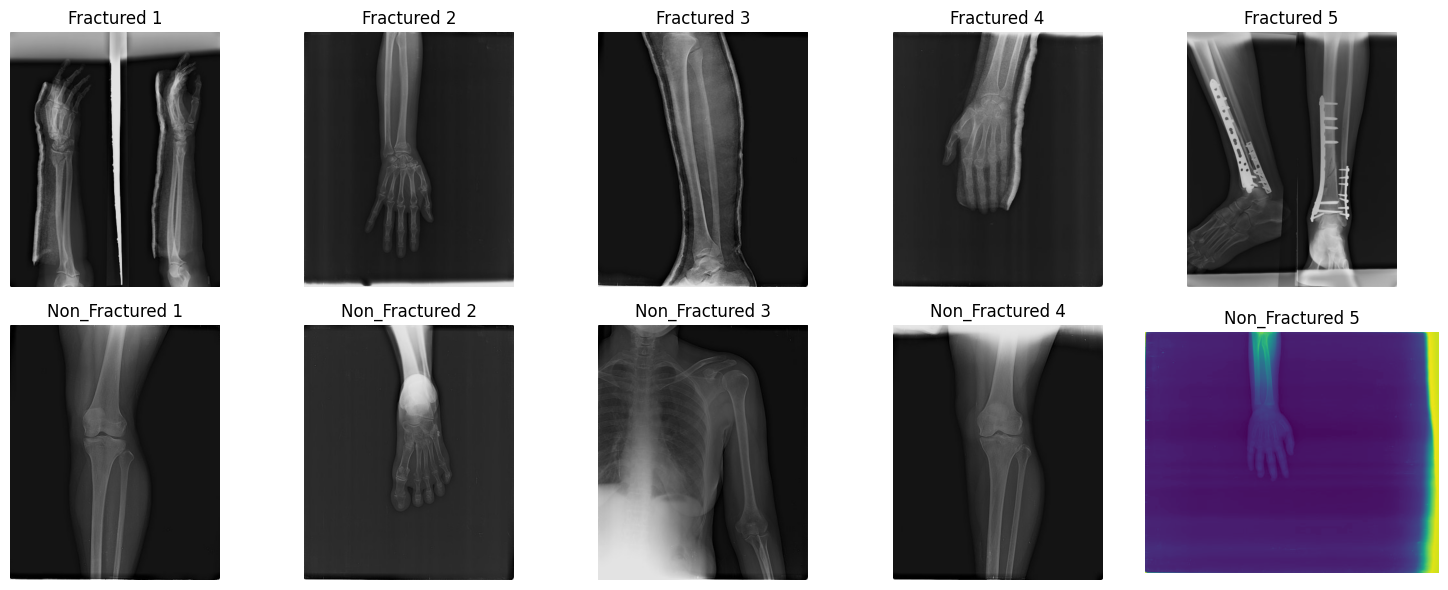

In [49]:
fractured_rows = df["image_id"].filter(df["fractured"] == 1)
nonfractured_rows = df["image_id"].filter(df["fractured"] == 0)

fractured_rows = fractured_rows.sample(n = 5)
nonfractured_rows = nonfractured_rows.sample(n = 5)

fractured_imgs = []

for img_path in fractured_rows:
    fractured_imgs.append(Image.open("../FracAtlas/images/Fractured/" + img_path))

nonfractured_imgs = []

for img_path in nonfractured_rows:
    nonfractured_imgs.append(Image.open("../FracAtlas/images/Non_fractured/" + img_path))
    
fig, axes = plt.subplots(2, 5, figsize = (15,6))

for i, img in enumerate(fractured_imgs):
    axes[0, i].imshow(img)
    axes[0, i].axis("off")
    axes[0, i].set_title(f"Fractured {i + 1}")
    
for i, img in enumerate(nonfractured_imgs):
    axes[1, i].imshow(img)
    axes[1, i].axis("off")
    axes[1, i].set_title(f"Non_Fractured {i + 1}")

plt.tight_layout()
plt.show()

It is important to note, that even if the paper has stated that images focusing on chest and skull were discarded, but when we examined the dataset further, even if the focus of the image might be the arm, or the leg, there are still a number of images where the chest and skull which may have been included in the scan.